# CREATE SUPPLEMENTARY FIGURE 2 PANELS
## last updated: 08.01.25

In [9]:
import pandas as pd

# note - the clustering module only works with numpy=1.24, so make sure this is the version installed!

%run 'ecDNAInspector_functions.ipynb'
print("ecDNAInspector functions loaded!")

ecDNAInspector functions loaded!


In [2]:
cycle_level_data_path = 'full_tool_testing/ic_intrasample_filt_cycle_data_w_conf.csv'

In [3]:
features = ["Cycle TPR", "Cycle FPR", "Cycle PFNR", "Cycle MEB"]
L=2
K=8
H=1000
resample_proportion=0.8
n_init=10

In [4]:
cycle_data = pd.read_csv(cycle_level_data_path)
cycle_data.reset_index(drop=True, inplace=True)
cycle_data = cycle_data[~cycle_data[features].eq("NF").any(axis=1)]
clustering_cycle_data = cycle_data[features]
print("Total cycles eligible for clustering: " + str(len(clustering_cycle_data)))

consensus_cluster = consensusClustering.ConsensusCluster(
    cluster=partial(KMeans, n_init=n_init),
    L=L,
    K=K,
    H=H,
    resample_proportion=resample_proportion
)

consensus_cluster.fit(clustering_cycle_data)

Total cycles eligible for clustering: 783


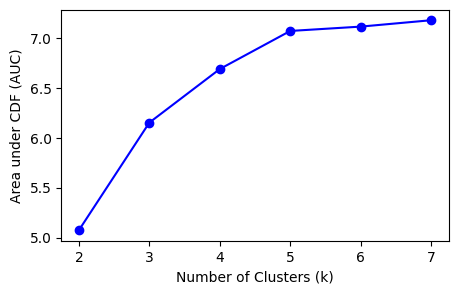

In [5]:
plt.figure(figsize=(5, 3))
plt.plot(range(L, K), consensus_cluster.Ak, marker='o', linestyle='-', color='b', label='Area under CDF')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Area under CDF (AUC)')
plt.xticks(range(L, K))
plt.grid(False)
plt.show()

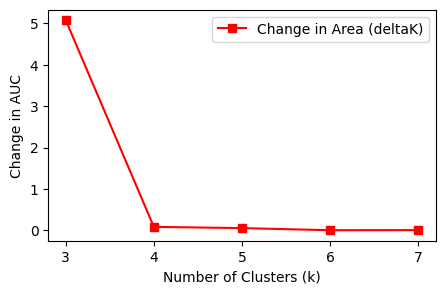

In [6]:
plt.figure(figsize=(5, 3))
plt.plot(range(L+1, K), consensus_cluster.deltaK, marker='s', linestyle='-', color='r', label='Change in Area (deltaK)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Change in AUC')
plt.xticks(range(L+1, K))
plt.grid(False)
plt.legend()
plt.show()

In [7]:
# note best_k is the index in the range tested
best_k = consensus_cluster.bestK
print(f"Best number of clusters (bestK): {best_k + 1}")

Best number of clusters (bestK): 3


In [8]:
# check with KMeans clustering

from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(clustering_cycle_data)

cc_labels = consensus_cluster.predict_data(clustering_cycle_data)

ari = adjusted_rand_score(kmeans_labels, cc_labels)
print(f"Adjusted Rand Index (ARI) between K-means and the other clustering: {ari:.4f}")

Adjusted Rand Index (ARI) between K-means and the other clustering: 0.7354
